# Transformer Model

In [4]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.utils.class_weight import compute_class_weight
# ═══════════════════════════════
# 1. DATASET CLASS
# ═══════════════════════════════
class PowerGridDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# ═══════════════════════════════
# 2. TRANSFORMER MODEL 
# ═══════════════════════════════
class PowerTransformer(nn.Module):
    def __init__(self, n_features, n_classes, n_heads=8, n_layers=6):
        super(PowerTransformer, self).__init__()
        
        self.d_model = 64 
        self.input_projection = nn.Linear(n_features, self.d_model)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.d_model, 
            nhead=n_heads, 
            dim_feedforward=128, 
            dropout=0.2,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        
        self.classifier = nn.Sequential(
            nn.Linear(self.d_model, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, n_classes)
        )

    def forward(self, x):
        # x shape: (batch, timesteps, features)
        x = self.input_projection(x) 
        x = self.transformer_encoder(x)
        # Global Average Pooling across the time dimension
        x = x.mean(dim=1) 
        return self.classifier(x)

# ═══════════════════════════════
# 3. PREPROCESSING
# ═══════════════════════════════

df = pd.read_csv("/content/drive/MyDrive/ORNL_Project/output/features_top_40.csv") 
X = df.drop(columns=["marker"]).replace([np.inf, -np.inf], np.nan).fillna(0)
y = df["marker"]

# Scaling & Encoding
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Create Sequences
TIMESTEPS = 30
def create_sequences(X, y, timesteps):
    Xs, ys = [], []
    for i in range(len(X) - timesteps):
        Xs.append(X[i:i+timesteps])
        ys.append(y[i+timesteps])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(X_scaled, y_encoded, TIMESTEPS)
X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=0.2, stratify=y_seq)
X_train,X_val,y_train,y_val = train_test_split(X_train, y_train, test_size=0.1, stratify=y_train)



# Setup DataLoaders
train_ds = PowerGridDataset(X_train, y_train)
test_ds = PowerGridDataset(X_test, y_test)
val_ds= PowerGridDataset(X_val, y_val)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=32)
val_loader = DataLoader(val_ds, batch_size=32)

# Class Weights
weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = torch.tensor(weights, dtype=torch.float32)

# ═══════════════════════════════
# 4. TRAINING and validation LOOP
# ═══════════════════════════════
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PowerTransformer(X.shape[1], len(le.classes_),n_layers=6).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Learning Rate Scheduler
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.1)

print(f"Training on {device}...")

EPOCHS = 60 
for epoch in range(EPOCHS):
    #training phase
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    train_loss, train_correct, train_total = 0, 0, 0
    
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        
        # Training accuracy calculation
        preds = torch.argmax(outputs, dim=1)
        train_correct += (preds == batch_y).sum().item()
        train_total += batch_y.size(0)
    avg_train_loss= train_loss / len(train_loader)
    avg_train_acc = 100 * train_correct / train_total
    
    # validation phase
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            
            val_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == batch_y).sum().item()
            val_total += batch_y.size(0)
            
    avg_val_loss = val_loss / len(val_loader)
    avg_val_acc = 100 * val_correct / val_total
    
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']
    
    print(f"Epoch {epoch+1}/{EPOCHS} | LR: {current_lr:.6f}" )
    print(f"Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_acc:.2f}%")
    print(f"Val Loss: {avg_val_loss:.4f} | Val Acc: {avg_val_acc:.2f}%")
    print("-" * 30)
    
# ═══════════════════════════════
# 5. EVALUATION
# ═══════════════════════════════
model.eval()
all_preds = []
all_true = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        outputs = model(batch_X.to(device))
        preds = torch.argmax(outputs, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_true.extend(batch_y.numpy())

# Final Metrics
final_acc = accuracy_score(all_true, all_preds)
print(f"\nFinal Test Accuracy: {final_acc * 100:.2f}%")


print("\nFinal PyTorch Transformer Report:")
print(classification_report(all_true, all_preds, target_names=le.classes_.astype(str)))

Training on cuda...
Epoch 1/60 | LR: 0.001000
Train Loss: 0.5543 | Train Acc: 71.03%
Val Loss: 0.4286 | Val Acc: 79.08%
------------------------------
Epoch 2/60 | LR: 0.001000
Train Loss: 0.4200 | Train Acc: 79.68%
Val Loss: 0.3556 | Val Acc: 81.16%
------------------------------
Epoch 3/60 | LR: 0.001000
Train Loss: 0.3663 | Train Acc: 79.88%
Val Loss: 0.3280 | Val Acc: 81.59%
------------------------------
Epoch 4/60 | LR: 0.001000
Train Loss: 0.3332 | Train Acc: 80.51%
Val Loss: 0.3084 | Val Acc: 82.28%
------------------------------
Epoch 5/60 | LR: 0.001000
Train Loss: 0.3097 | Train Acc: 81.28%
Val Loss: 0.2718 | Val Acc: 82.96%
------------------------------
Epoch 6/60 | LR: 0.001000
Train Loss: 0.2999 | Train Acc: 81.64%
Val Loss: 0.3088 | Val Acc: 80.95%
------------------------------
Epoch 7/60 | LR: 0.001000
Train Loss: 0.2865 | Train Acc: 81.87%
Val Loss: 0.2585 | Val Acc: 80.23%
------------------------------
Epoch 8/60 | LR: 0.001000
Train Loss: 0.2569 | Train Acc: 83.37

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
import os
os.makedirs("/content/drive/MyDrive/ORNL_Project/output", exist_ok=True)

# LSTM Model

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from collections import Counter
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
# =========================================================
# LOAD DATA
# =========================================================

df = pd.read_csv("/content/drive/MyDrive/ORNL_Project/output/features_top_40.csv")

X = df.drop(columns=["marker"]).replace([np.inf, -np.inf], np.nan).fillna(0)
y = df["marker"]


In [8]:

# =========================================================
# ENCODE LABELS
# =========================================================

le = LabelEncoder()
y = le.fit_transform(y)

# =========================================================
# NORMALIZE FEATURES
# =========================================================

scaler = StandardScaler()
X = scaler.fit_transform(X)

# =========================================================
# CREATE TIME SERIES SEQUENCES
# =========================================================

TIMESTEPS = 30

Xs = []
ys = []

for i in range(len(X) - TIMESTEPS):

    # Previous 10 rows
    Xs.append(X[i:i+TIMESTEPS])

    # Predict next row class
    ys.append(y[i+TIMESTEPS])

X_seq = np.array(Xs)
y_seq = np.array(ys)

print("Sequence Shape:", X_seq.shape)
print("Label Shape:", y_seq.shape)

# =========================================================
# TRAIN / VALIDATION / TEST SPLIT
# =========================================================

# First split: Train+Val and Test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_seq,
    y_seq,
    test_size=0.20,
    random_state=42,
    stratify=y_seq
)

# Second split: Train and Validation
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval,
    y_trainval,
    test_size=0.125,  # 0.125 x 0.80 = 0.10
    random_state=42,
    stratify=y_trainval
)

print("\nTrain Shape:", X_train.shape)
print("Validation Shape:", X_val.shape)
print("Test Shape:", X_test.shape)

# =========================================================
# CONVERT TO PYTORCH TENSORS
# =========================================================

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)

X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

# =========================================================
# DATALOADERS
# =========================================================

train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)

# =========================================================
# LSTM MODEL
# =========================================================

class LSTMModel(nn.Module):

    def __init__(self, input_size, hidden_size, num_classes):

        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=2,
            batch_first=True,
            dropout=0.2
        )


        self.fc = nn.Sequential(
            nn.Linear(hidden_size , 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):

        out, _ = self.lstm(x)

        # Take final timestep output
        out = out[:, -1, :]

        out = self.fc(out)

        return out

# =========================================================
# INITIALIZE MODEL
# =========================================================

input_size = X.shape[1]
hidden_size = 64
num_classes = len(le.classes_)

model = LSTMModel(input_size, hidden_size, num_classes)

# =========================================================
# CLASS WEIGHTS
# =========================================================

class_counts = Counter(y_train)

class_weights = [1.0 / class_counts[i] for i in range(num_classes)]

class_weights = torch.tensor(class_weights, dtype=torch.float32)

class_weights = class_weights / class_weights.sum() * num_classes

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.AdamW(
    model.parameters(),
    lr=0.0005,
    weight_decay=1e-4
    )

# =========================================================
# TRAINING
# =========================================================

EPOCHS = 30

print("\nTraining LSTM...\n")

for epoch in range(EPOCHS):

    # ---------------- TRAIN ----------------

    model.train()

    train_loss = 0
    correct_train = 0
    total_train = 0

    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()

        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        # TRAIN ACCURACY
        _, predicted = torch.max(outputs, 1)
        total_train += y_batch.size(0)
        correct_train += (predicted == y_batch).sum().item()

    avg_train_loss = train_loss / len(train_loader)
    train_accuracy = correct_train / total_train
    

    # ---------------- VALIDATION ----------------

    model.eval()

    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            outputs = model(X_batch)

            loss = criterion(outputs, y_batch)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += y_batch.size(0)

            correct += (predicted == y_batch).sum().item()

    avg_val_loss = val_loss / len(val_loader)

    val_accuracy = correct / total

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Train Acc: {train_accuracy*100:.2f}% | "
        f"Val Loss: {avg_val_loss:.4f} | "
        f"Val Acc: {val_accuracy*100:.2f}%"
    )

# =========================================================
# FINAL TEST EVALUATION
# =========================================================

model.eval()

with torch.no_grad():

    outputs = model(X_test_t)

    _, predicted = torch.max(outputs, 1)

    test_accuracy = (predicted == y_test_t).float().mean().item()

print("\n================================================")
print(f"FINAL TEST ACCURACY: {test_accuracy*100:.2f}%")
print("================================================")

torch.save(model.state_dict(), "/content/drive/MyDrive/ORNL_Project/output/lstm_model.pth")
print("Model permanently saved to Google Drive!")

# -----------------------------------------------------------------
# =========================================================
# CLASSIFICATION REPORT
# =========================================================

print("\nClassification Report:\n")

print(classification_report(
    y_test_t.numpy(),
    predicted.numpy(),
    target_names=[str(c) for c in le.classes_]
))

Sequence Shape: (78347, 30, 37)
Label Shape: (78347,)

Train Shape: (54842, 30, 37)
Validation Shape: (7835, 30, 37)
Test Shape: (15670, 30, 37)

Training LSTM...

Epoch [1/30] | Train Loss: 0.6908 | Train Acc: 52.77% | Val Loss: 0.5305 | Val Acc: 70.54%
Epoch [2/30] | Train Loss: 0.4244 | Train Acc: 74.65% | Val Loss: 0.3479 | Val Acc: 78.06%
Epoch [3/30] | Train Loss: 0.3363 | Train Acc: 79.00% | Val Loss: 0.3154 | Val Acc: 81.12%
Epoch [4/30] | Train Loss: 0.2986 | Train Acc: 80.63% | Val Loss: 0.2801 | Val Acc: 81.84%
Epoch [5/30] | Train Loss: 0.2731 | Train Acc: 81.97% | Val Loss: 0.2439 | Val Acc: 84.20%
Epoch [6/30] | Train Loss: 0.2562 | Train Acc: 82.98% | Val Loss: 0.2313 | Val Acc: 83.92%
Epoch [7/30] | Train Loss: 0.2467 | Train Acc: 83.55% | Val Loss: 0.2279 | Val Acc: 84.35%
Epoch [8/30] | Train Loss: 0.2204 | Train Acc: 85.30% | Val Loss: 0.1977 | Val Acc: 86.99%
Epoch [9/30] | Train Loss: 0.2039 | Train Acc: 86.35% | Val Loss: 0.1897 | Val Acc: 86.38%
Epoch [10/30] | T

✅ Model loaded successfully!
   Classes: [np.int64(0), np.int64(1), np.int64(2)]
   Test samples: 15670

Detected 3662 actual attack samples in your test split.
✅ Saliency computed over 50 real attack sequences.


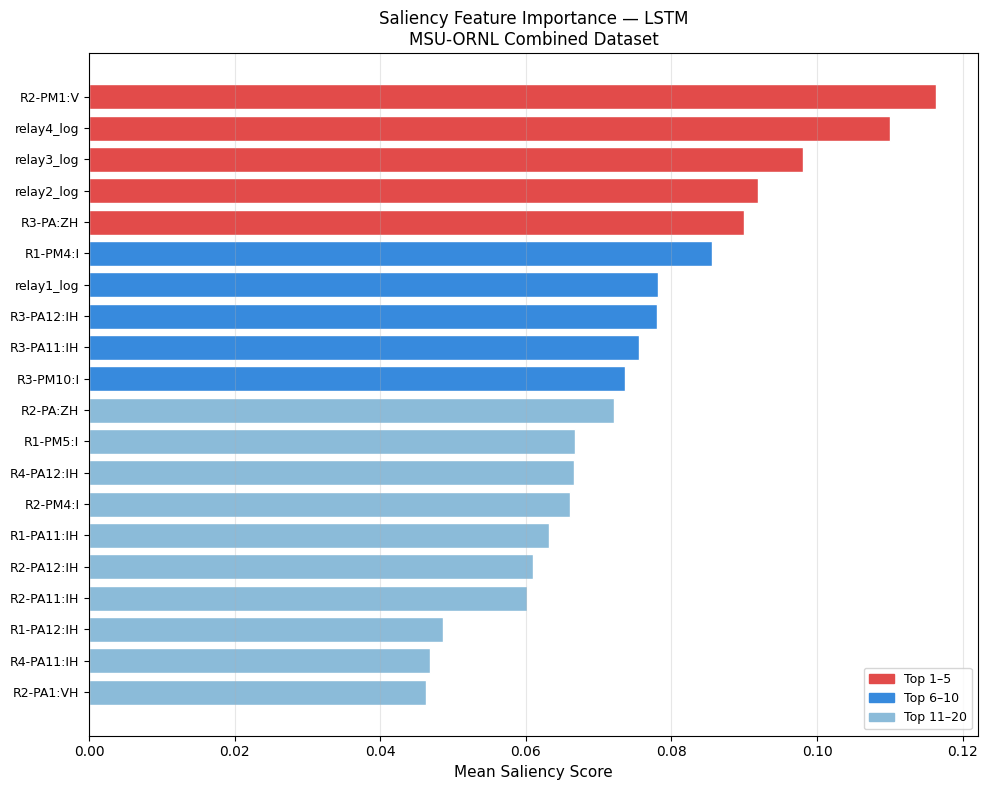

✅ Figure 1 saved!


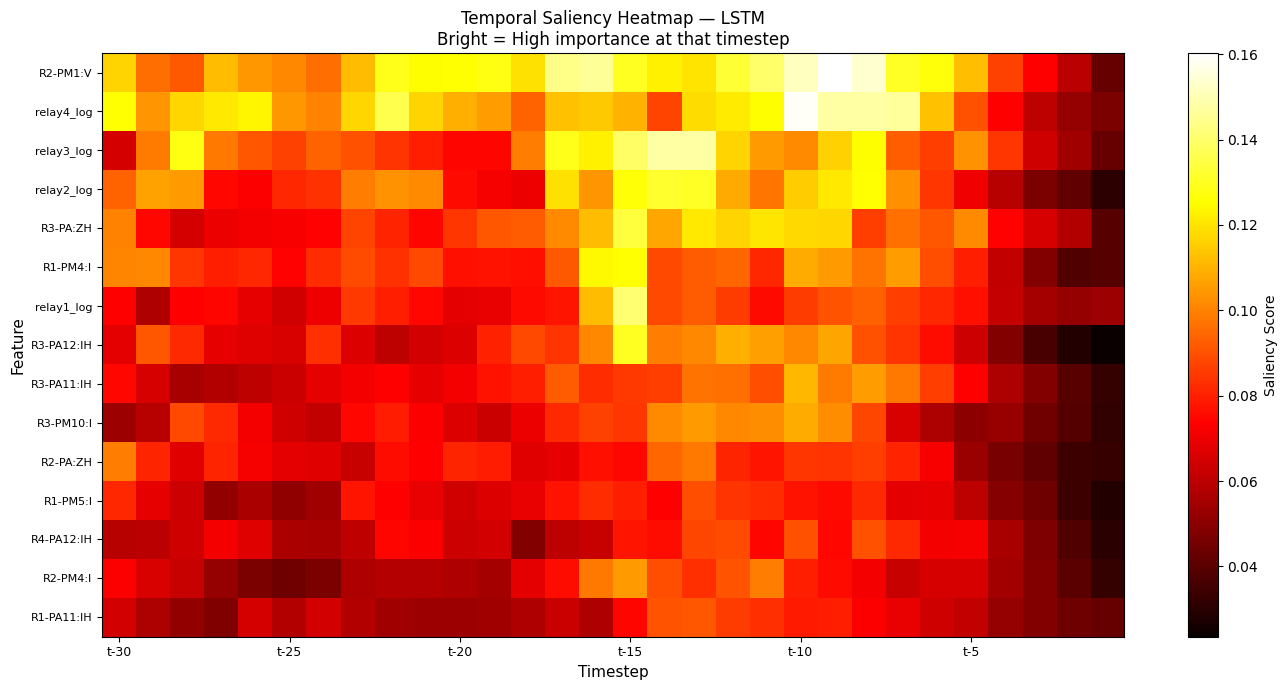

✅ Figure 2 saved!

TOP 10 FEATURES — Copy to your paper
   1. R2-PM1:V                       0.116306
   2. relay4_log                     0.110038
   3. relay3_log                     0.098042
   4. relay2_log                     0.091856
   5. R3-PA:ZH                       0.090002
   6. R1-PM4:I                       0.085556
   7. relay1_log                     0.078115
   8. R3-PA12:IH                     0.078075
   9. R3-PA11:IH                     0.075567
  10. R3-PM10:I                      0.073637


In [ ]:
# ═══════════════════════════════════════════════
# saliency_analysis.py
# ═══════════════════════════════════════════════

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.preprocessing import LabelEncoder, StandardScaler

# ── Step 1: Data load 
df = pd.read_csv("/content/drive/MyDrive/ORNL_Project/output/features_top_40.csv")

X = df.drop(columns=["marker"]).replace([np.inf, -np.inf], np.nan).fillna(0)
y = df["marker"]

feature_names = [c for c in df.columns if c != 'marker']

le = LabelEncoder()
y = le.fit_transform(y)

scaler = StandardScaler()
X = scaler.fit_transform(X)

# ── Step 2: Sequences 
TIMESTEPS = 30
Xs, ys = [], []

for i in range(len(X) - TIMESTEPS):
    Xs.append(X[i:i+TIMESTEPS])
    ys.append(y[i+TIMESTEPS])

X_seq = np.array(Xs)
y_seq = np.array(ys)

# ── Step 3: Test split  ──────────
from sklearn.model_selection import train_test_split

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_seq, y_seq, test_size=0.20, random_state=42, stratify=y_seq
)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

# ── Step 4: Model define 
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=2,
            batch_first=True,
            dropout=0.2
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out)

# ── Step 5: Saved model load 
input_size  = X.shape[1]          # 37
hidden_size = 64
num_classes = len(le.classes_)    # 3

model = LSTMModel(input_size, hidden_size, num_classes)
model.load_state_dict(torch.load("/content/drive/MyDrive/ORNL_Project/output/lstm_model.pth", map_location='cpu'))

print("✅ Model loaded successfully!")
print(f"   Classes: {list(le.classes_)}")
print(f"   Test samples: {len(X_test_t)}")

# ── Step 6: Saliency function ─────────────────────
def compute_saliency(model, input_tensor, target_class):
    inp = input_tensor.clone().requires_grad_(True)
    output = model(inp)
    score = output[0, target_class]
    model.zero_grad()
    score.backward()
    return inp.grad.data.abs().squeeze().numpy()  # (30, 37)

# ── Step 7: 50 attack sample  average saliency ──
# ── Step 7: Dynamic Target Saliency Computation ──
# Find the exact encoded integer for the 'Attack' label dynamically

attack_label_idx = le.transform(['Attack'])[0] if 'Attack' in le.classes_ else 1

attack_indices = np.where(y_test == attack_label_idx)[0]
print(f"\nDetected {len(attack_indices)} actual attack samples in your test split.")

all_saliency = []
n_samples = min(50, len(attack_indices))

for idx in attack_indices[:n_samples]:
    sample = X_test_t[idx:idx+1]
    # Pass the real attack class index dynamically instead of a hardcoded 0
    sal = compute_saliency(model, sample, target_class=attack_label_idx)
    all_saliency.append(sal)

avg_saliency = np.mean(all_saliency, axis=0)       # (30, 37)
feature_importance = avg_saliency.mean(axis=0)     # (37,)
sorted_idx = np.argsort(feature_importance)[::-1]

print(f"✅ Saliency computed over {n_samples} real attack sequences.")

# ═══════════════════════════════════════════════
# FIGURE 1: Feature Importance Bar Chart
# ═══════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 8))

top_n = 20
colors = ['#E24B4A']*5 + ['#378ADD']*5 + ['#8BBBD9']*10

ax.barh(range(top_n),
        feature_importance[sorted_idx[:top_n]],
        color=colors, edgecolor='white')

ax.set_yticks(range(top_n))
ax.set_yticklabels([feature_names[i] for i in sorted_idx[:top_n]], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Mean Saliency Score", fontsize=11)
ax.set_title("Saliency Feature Importance — LSTM\nMSU-ORNL Combined Dataset", fontsize=12)
ax.grid(axis='x', alpha=0.3)

r = mpatches.Patch(color='#E24B4A', label='Top 1–5')
b = mpatches.Patch(color='#378ADD', label='Top 6–10')
l = mpatches.Patch(color='#8BBBD9', label='Top 11–20')
ax.legend(handles=[r, b, l], fontsize=9)

plt.tight_layout()
plt.savefig("saliency_feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure 1 saved!")

# ═══════════════════════════════════════════════
# FIGURE 2: Temporal Heatmap
# ═══════════════════════════════════════════════
top15_idx   = sorted_idx[:15]
sal_subset  = avg_saliency[:, top15_idx].T   # (15, 30)
top15_names = [feature_names[i] for i in top15_idx]

fig, ax = plt.subplots(figsize=(14, 7))
im = ax.imshow(sal_subset, aspect='auto', cmap='hot', interpolation='nearest')
plt.colorbar(im, ax=ax, label='Saliency Score')

ax.set_xlabel("Timestep", fontsize=11)
ax.set_ylabel("Feature", fontsize=11)
ax.set_title("Temporal Saliency Heatmap — LSTM\nBright = High importance at that timestep", fontsize=12)
ax.set_yticks(range(15))
ax.set_yticklabels(top15_names, fontsize=8)
ax.set_xticks(range(0, 30, 5))
ax.set_xticklabels([f"t-{30-i}" for i in range(0, 30, 5)], fontsize=9)

plt.tight_layout()
plt.savefig("saliency_temporal_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure 2 saved!")

# ── Print top features ────────────────────────────
print("\n" + "="*50)
print("TOP 10 FEATURES — Copy to your paper")
print("="*50)
for rank, idx in enumerate(sorted_idx[:10], 1):
    print(f"  {rank:2d}. {feature_names[idx]:30s} {feature_importance[idx]:.6f}")

In [3]:
print(df.shape)
print(df.columns)

(78377, 38)
Index(['R2-PM1:V', 'R1-PM5:I', 'R3-PM10:I', 'R2-PM4:I', 'R1-PM4:I', 'R3-PA:ZH',
       'R2-PA:ZH', 'R1-PA3:VH', 'R1-PA1:VH', 'R1-PA2:VH', 'R2-PA1:VH',
       'R2-PA3:VH', 'R2-PA2:VH', 'R1-PA5:IH', 'R4-PA5:IH', 'R2-PA5:IH',
       'R3-PA5:IH', 'R4-PA6:IH', 'R4-PA4:IH', 'R1-PA4:IH', 'R3-PA4:IH',
       'R1-PA6:IH', 'R2-PA4:IH', 'R2-PA6:IH', 'R3-PA6:IH', 'R1-PA12:IH',
       'R3-PA12:IH', 'R2-PA12:IH', 'R1-PA11:IH', 'R4-PA12:IH', 'R2-PA11:IH',
       'R4-PA11:IH', 'R3-PA11:IH', 'relay4_log', 'relay3_log', 'relay2_log',
       'relay1_log', 'marker'],
      dtype='object')


In [1]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
from sklearn.metrics import classification_report, confusion_matrix

In [13]:
# =========================================================
# ENCODE LABELS
# =========================================================

le = LabelEncoder()
y = le.fit_transform(y)

# =========================================================
# NORMALIZE FEATURES
# =========================================================

scaler = StandardScaler()
X = scaler.fit_transform(X)

# =========================================================
# CREATE TIME SERIES SEQUENCES
# =========================================================

TIMESTEPS = 30

Xs = []
ys = []

for i in range(len(X) - TIMESTEPS):

    # Previous 10 rows
    Xs.append(X[i:i+TIMESTEPS])

    # Predict next row class
    ys.append(y[i+TIMESTEPS])

X_seq = np.array(Xs)
y_seq = np.array(ys)

print("Sequence Shape:", X_seq.shape)
print("Label Shape:", y_seq.shape)

# =========================================================
# TRAIN / VALIDATION / TEST SPLIT
# =========================================================

# First split: Train+Val and Test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_seq,
    y_seq,
    test_size=0.20,
    random_state=42,
    stratify=y_seq
)

# Second split: Train and Validation
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval,
    y_trainval,
    test_size=0.125,  # 0.125 x 0.80 = 0.10
    random_state=42,
    stratify=y_trainval
)

print("\nTrain Shape:", X_train.shape)
print("Validation Shape:", X_val.shape)
print("Test Shape:", X_test.shape)

# =========================================================
# CONVERT TO PYTORCH TENSORS
# =========================================================

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)

X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

# =========================================================
# DATALOADERS
# =========================================================

train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)

# =========================================================
# LSTM MODEL
# =========================================================

class LSTMModel(nn.Module):

    def __init__(self, input_size, hidden_size, num_classes):

        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=2,
            batch_first=True,
            dropout=0.2
        )


        self.fc = nn.Sequential(
            nn.Linear(hidden_size , 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):

        out, _ = self.lstm(x)

        # Take final timestep output
        out = out[:, -1, :]

        out = self.fc(out)

        return out

Sequence Shape: (78347, 30, 37)
Label Shape: (78347,)

Train Shape: (54842, 30, 37)
Validation Shape: (7835, 30, 37)
Test Shape: (15670, 30, 37)


✅ Saved model successfully loaded from Google Drive!

FINAL TEST ACCURACY: 98.12%

              precision    recall  f1-score   support

           0       0.99      0.98      0.99     11133
           1       0.95      0.98      0.97      3662
           2       0.95      1.00      0.97       875

    accuracy                           0.98     15670
   macro avg       0.97      0.99      0.98     15670
weighted avg       0.98      0.98      0.98     15670

DETAILED METRICS PER CLASS (TP, FP, FN, TN)

--- Class 0: 0 ---
  True Positives  (TP):  10910
  False Positives (FP):     64
  False Negatives (FN):    223
  True Negatives  (TN):   4473

--- Class 1: 1 ---
  True Positives  (TP):   3593
  False Positives (FP):    187
  False Negatives (FN):     69
  True Negatives  (TN):  11821

--- Class 2: 2 ---
  True Positives  (TP):    872
  False Positives (FP):     44
  False Negatives (FN):      3
  True Negatives  (TN):  14751


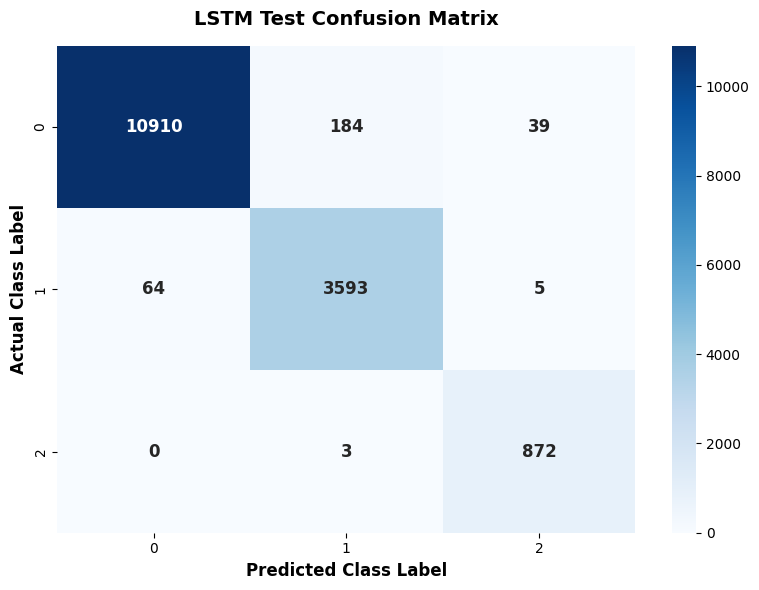

In [18]:
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# 1. INITIALIZE & LOAD SAVED MODEL FROM GOOGLE DRIVE
input_size = X.shape[1]
hidden_size = 64
num_classes = len(le.classes_)

model = LSTMModel(input_size, hidden_size, num_classes)

model_path = "/content/drive/MyDrive/ORNL_Project/output/lstm_model.pth"
model.load_state_dict(torch.load(model_path, map_location=torch.device('cpu')))
model.eval()

print("✅ Saved model successfully loaded from Google Drive!")

# 2. MAKE PREDICTIONS ON TEST SET
with torch.no_grad():
    outputs = model(X_test_t)
    _, predicted = torch.max(outputs, 1)
    test_accuracy = (predicted == y_test_t).float().mean().item()

print(f"\nFINAL TEST ACCURACY: {test_accuracy*100:.2f}%\n")
print(classification_report(y_test_t.numpy(), predicted.numpy(), target_names=[str(c) for c in le.classes_]))

# 3. CONFUSION MATRIX & TP/FP/FN/TN
cm = confusion_matrix(y_test_t.numpy(), predicted.numpy())
total_samples = np.sum(cm)

print("="*50)
print("DETAILED METRICS PER CLASS (TP, FP, FN, TN)")
print("="*50)

for i in range(len(le.classes_)):
    class_name = str(le.classes_[i])
    TP = cm[i, i]
    FP = cm[:, i].sum() - TP
    FN = cm[i, :].sum() - TP
    TN = total_samples - (TP + FP + FN)
    
    print(f"\n--- Class {i}: {class_name} ---")
    print(f"  True Positives  (TP): {TP:6d}")
    print(f"  False Positives (FP): {FP:6d}")
    print(f"  False Negatives (FN): {FN:6d}")
    print(f"  True Negatives  (TN): {TN:6d}")

# 4. SAVE HEATMAP IMAGE FOR PAPER
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=le.classes_, yticklabels=le.classes_,
            annot_kws={"size": 12, "weight": "bold"})
plt.xlabel('Predicted Class Label', fontsize=12, fontweight='bold')
plt.ylabel('Actual Class Label', fontsize=12, fontweight='bold')
plt.title('LSTM Test Confusion Matrix', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/ORNL_Project/output/lstm_confusion_matrix.png", dpi=300)
plt.show()


Generating Clean SHAP Waterfall Plots...
--- Processing True_Positive ---


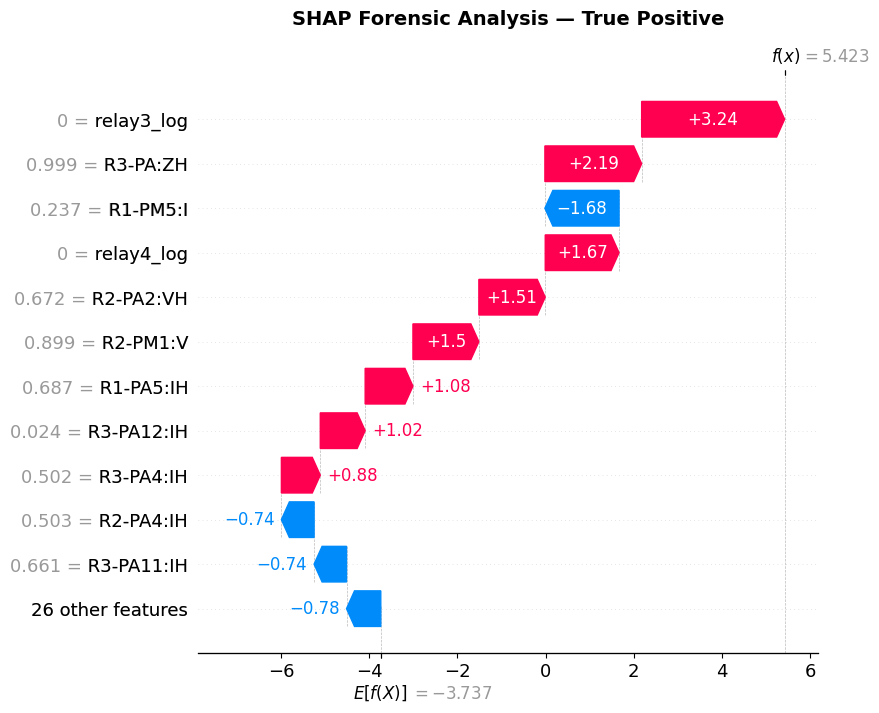

✅ Clean image saved: /content/drive/MyDrive/ORNL_Project/output/SHAP_Waterfall_True_Positive.png

--- Processing True_Negative ---


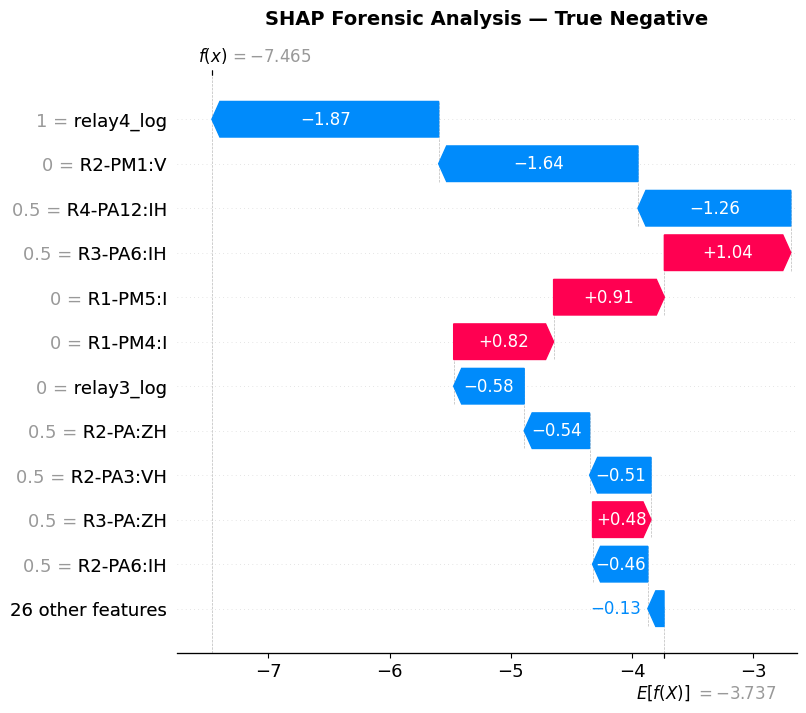

✅ Clean image saved: /content/drive/MyDrive/ORNL_Project/output/SHAP_Waterfall_True_Negative.png

--- Processing False_Positive ---


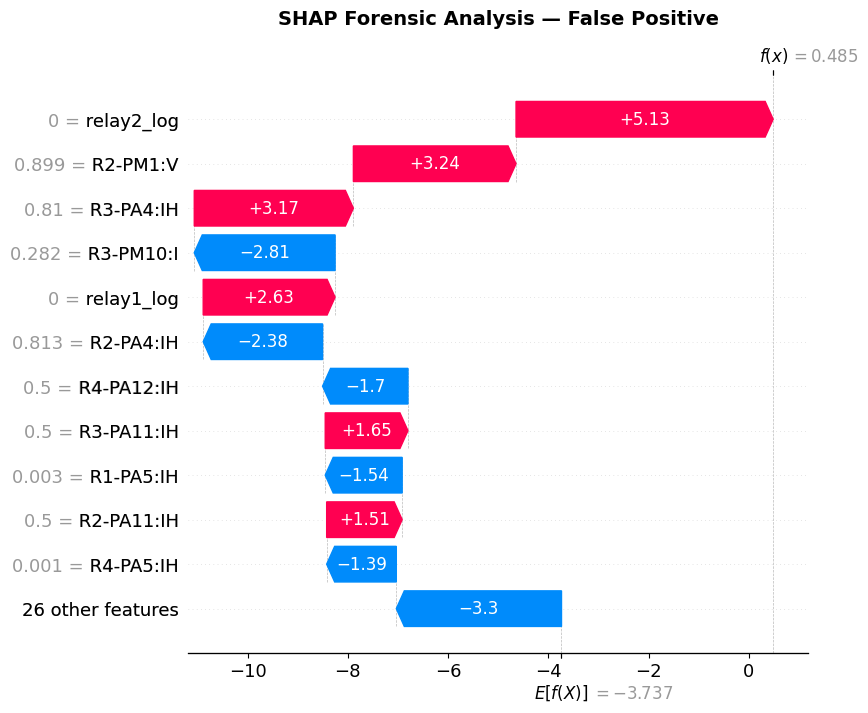

✅ Clean image saved: /content/drive/MyDrive/ORNL_Project/output/SHAP_Waterfall_False_Positive.png

--- Processing False_Negative ---


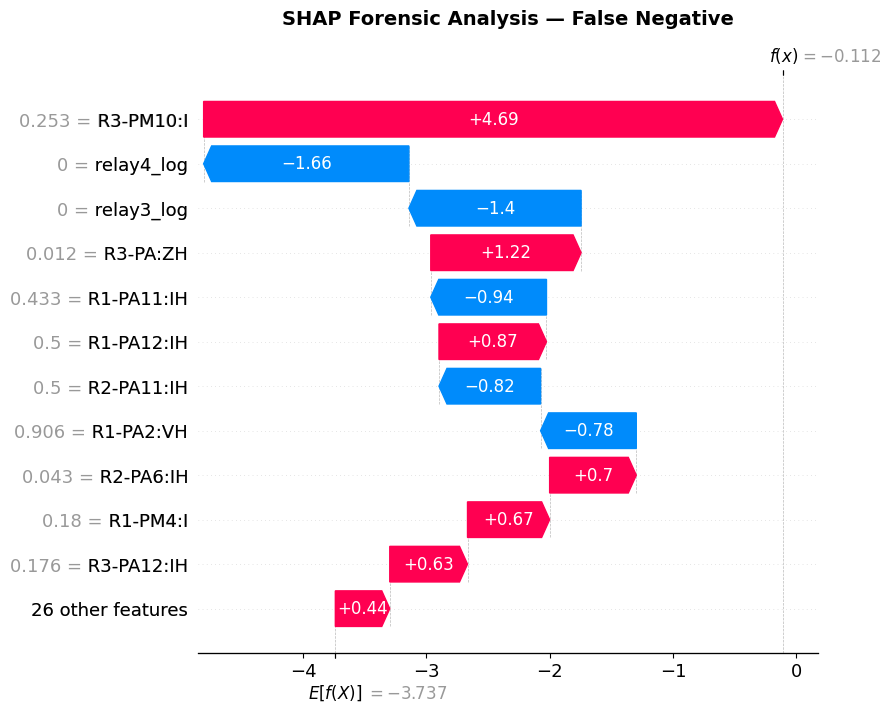

✅ Clean image saved: /content/drive/MyDrive/ORNL_Project/output/SHAP_Waterfall_False_Negative.png



In [20]:
!pip install shap -q
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

# 0. LOAD FEATURE NAMES
df_temp = pd.read_csv("/content/drive/MyDrive/ORNL_Project/output/features_top_40.csv", nrows=0)
feature_names = [c for c in df_temp.columns if c != 'marker']

# 1. SETUP EXPLAINER
model.eval()
background_samples = X_train_t[:100].to(torch.device('cpu'))
explainer = shap.GradientExplainer(model, background_samples)

with torch.no_grad():
    bg_outputs = model(background_samples)
    base_val = bg_outputs.mean(dim=0)[1].item() # Attack class base value

with torch.no_grad():
    outputs = model(X_test_t)
    _, predicted = torch.max(outputs, dim=1)

y_true_np = y_test_t.numpy()
y_pred_np = predicted.numpy()
attack_idx = le.transform(['Attack'])[0] if 'Attack' in le.classes_ else 1

# 2. FIND SAMPLE INDICES
cases = {
    "True_Positive": np.where((y_true_np == attack_idx) & (y_pred_np == attack_idx))[0][0],
    "True_Negative": np.where((y_true_np != attack_idx) & (y_pred_np != attack_idx))[0][0],
    "False_Positive": np.where((y_true_np != attack_idx) & (y_pred_np == attack_idx))[0][0],
    "False_Negative": np.where((y_true_np == attack_idx) & (y_pred_np != attack_idx))[0][0]
}

# 3. ROUND VALUES TO 3 DECIMALS SO TEXT IS CLEAN AND SHORT!
X_test_orig = np.round(scaler.inverse_transform(X_test[:, -1, :]), 3)

print("\nGenerating Clean SHAP Waterfall Plots...")
for case_name, idx in cases.items():
    print(f"--- Processing {case_name} ---")
    
    sample_tensor = X_test_t[idx:idx+1]
    shap_vals = explainer.shap_values(sample_tensor)
    
    if isinstance(shap_vals, list):
        sal_seq = shap_vals[attack_idx][0]
    else:
        sal_seq = shap_vals[0, :, :, attack_idx] if shap_vals.ndim == 4 else shap_vals[0]
        
    feature_shap_contributions = np.sum(sal_seq, axis=0)
    
    # Create a SHAP Explanation object for clean modern plotting
    explanation = shap.Explanation(
        values=feature_shap_contributions,
        base_values=base_val,
        data=X_test_orig[idx],
        feature_names=feature_names
    )
    
    # Generate a vertical WATERFALL plot (Zero overlapping text!)
    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(explanation, max_display=12, show=False)
    
    plt.title(f"SHAP Forensic Analysis — {case_name.replace('_', ' ')}", fontsize=14, fontweight='bold', pad=15)
    
    filename = f"/content/drive/MyDrive/ORNL_Project/output/SHAP_Waterfall_{case_name}.png"
    plt.savefig(filename, dpi=1000, bbox_inches='tight')
    plt.show()
    print(f"✅ Clean image saved: {filename}\n")

In [ ]:
import shap
import matplotlib.pyplot as plt

# List your 4 cases clearly
case_data = {
    "True_Positive": cases["True Positive"],
    "True_Negative": cases["True Negative"],
    "False_Positive": cases["False Positive"],
    "False_Negative": cases["False Negative"]
}

for name, idx in case_data.items():
    sample_tensor = X_test_t[idx : idx + 1]
    shap_vals = explainer.shap_values(sample_tensor)
    sal_seq = shap_vals[attack_idx][0] if isinstance(shap_vals, list) else (shap_vals[0, :, :, attack_idx] if shap_vals.ndim == 4 else shap_vals[0])
    
    explanation = shap.Explanation(
        values=np.sum(sal_seq, axis=0),
        base_values=base_val,
        data=X_test_orig[idx],
        feature_names=feature_names
    )
    
    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(explanation, max_display=8, show=False)
    plt.title(name.replace('_', ' '), fontsize=14, fontweight='bold')
    plt.savefig(f"/content/drive/MyDrive/ORNL_Project/output/waterfall_{name}.png", bbox_inches='tight', dpi=900)
    plt.close()

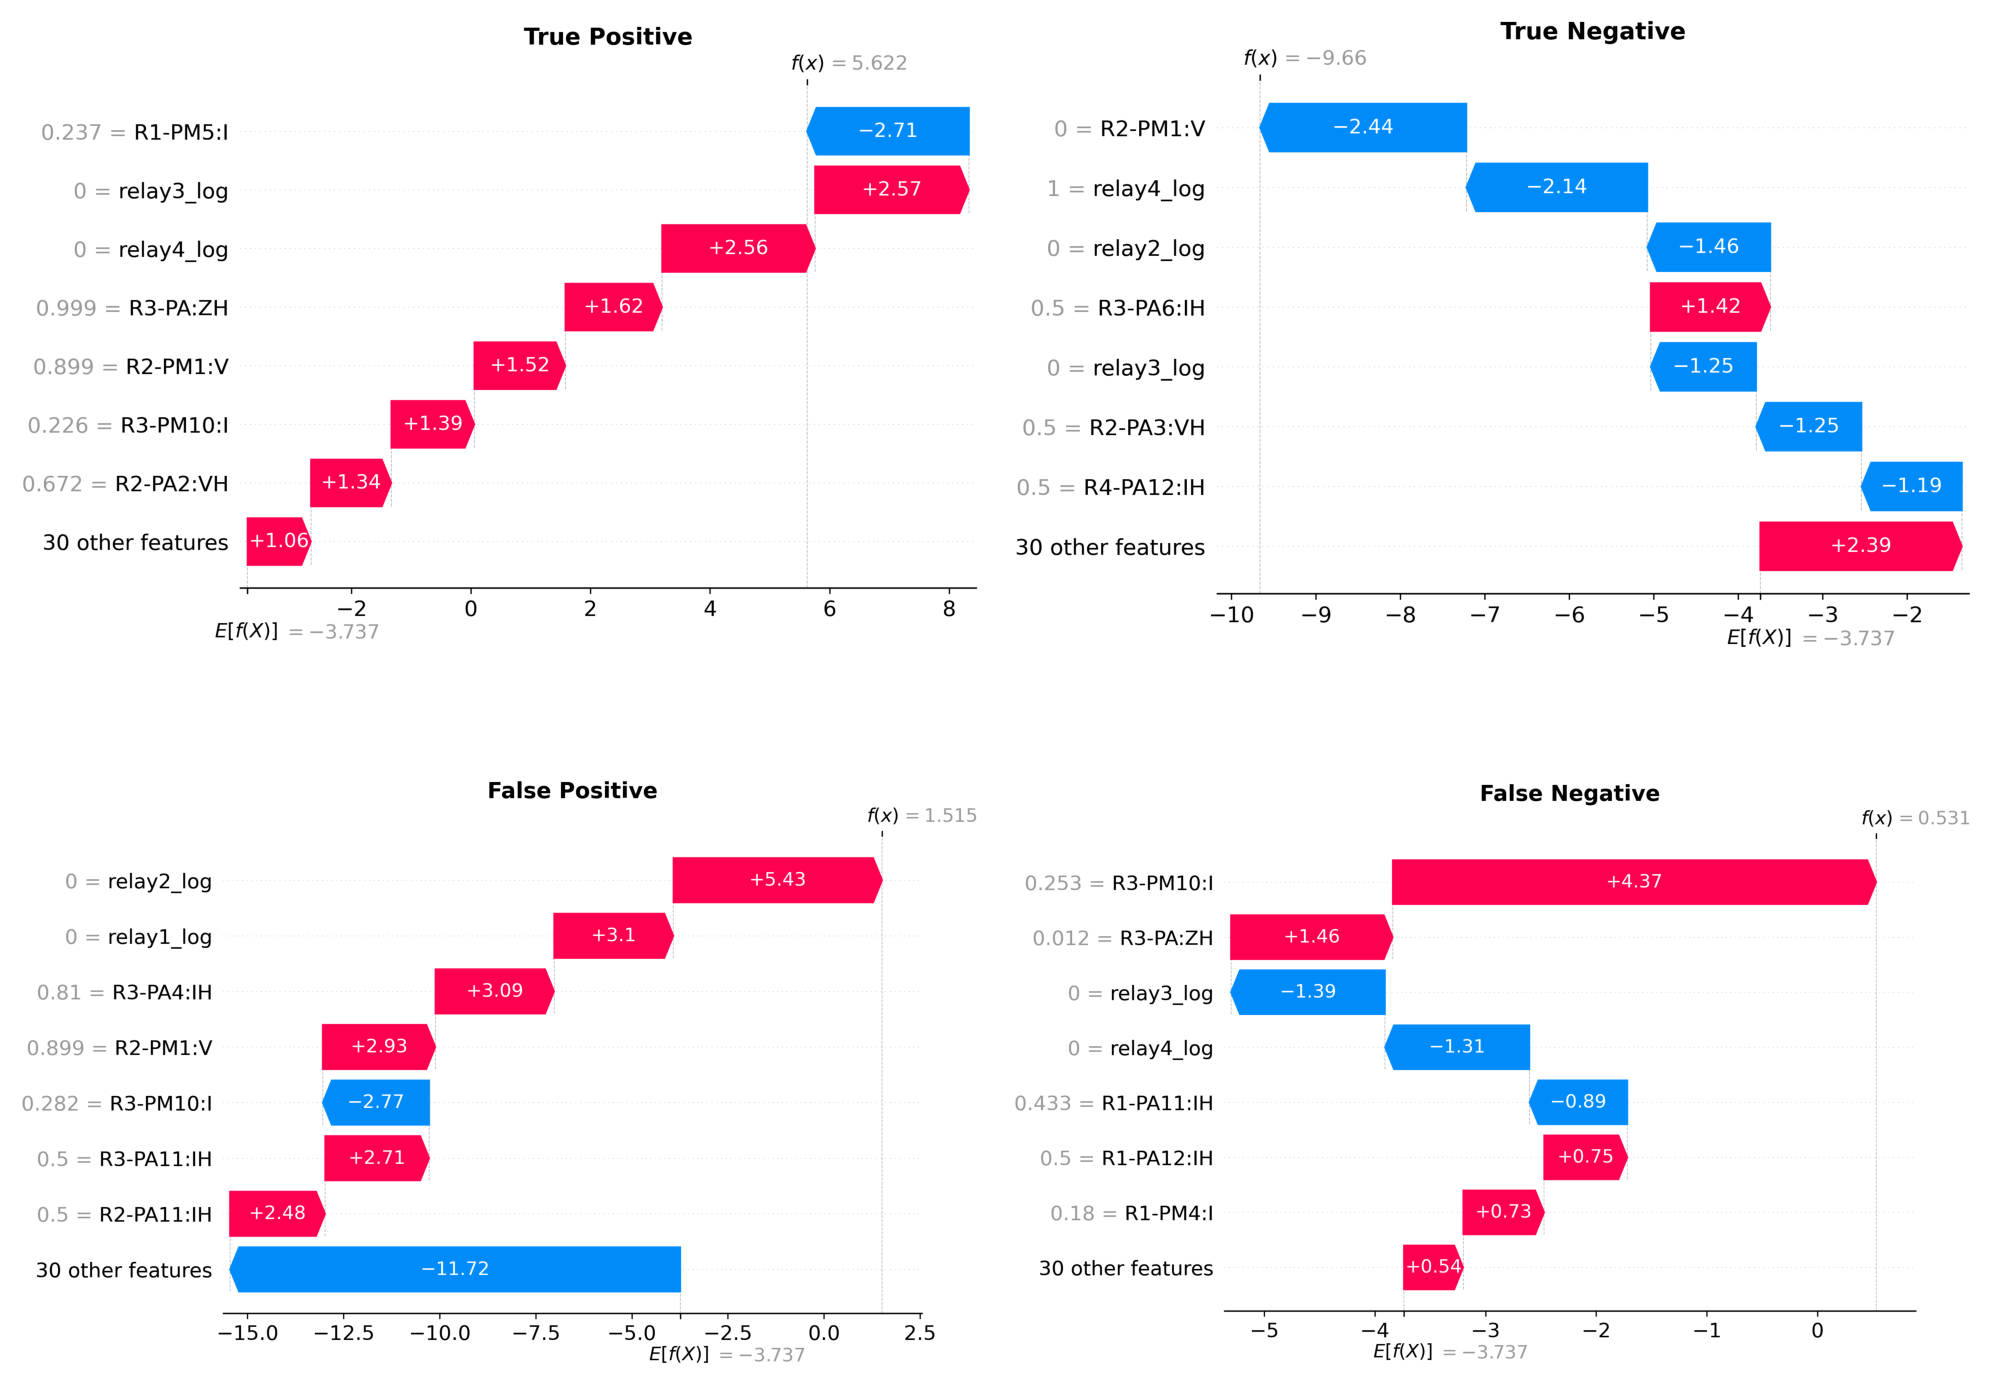

In [25]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Load the saved images
img1 = mpimg.imread("/content/drive/MyDrive/ORNL_Project/output/waterfall_True_Positive.png")
img2 = mpimg.imread("/content/drive/MyDrive/ORNL_Project/output/waterfall_True_Negative.png")
img3 = mpimg.imread("/content/drive/MyDrive/ORNL_Project/output/waterfall_False_Positive.png")
img4 = mpimg.imread("/content/drive/MyDrive/ORNL_Project/output/waterfall_False_Negative.png")

# Create the 2x2 Grid
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
axes[0, 0].imshow(img1); axes[0, 0].axis('off')
axes[0, 1].imshow(img2); axes[0, 1].axis('off')
axes[1, 0].imshow(img3); axes[1, 0].axis('off')
axes[1, 1].imshow(img4); axes[1, 1].axis('off')

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/ORNL_Project/output/Final_2x2_Waterfall_Grid.png", dpi=900)
plt.show()